# Music Genre classifier

**Name: Jonathan Porter**

Dataset: https://www.kaggle.com/datasets/asisheriberto/music-classification-wav

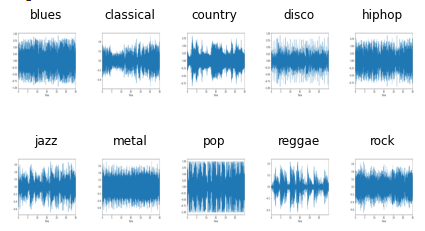

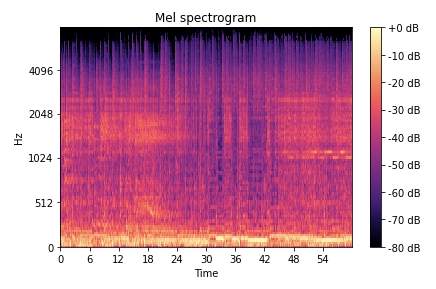

In [ ]:
#@title Imports
import torch
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import librosa.display
import random
import torch
from torchvision.models import vgg16
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from sklearn.model_selection import train_test_split
import cv2
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
import keras.utils
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
import seaborn as sns

In [ ]:
#@title GPU, Connection check to local host

#checks for gpu activity: if active the message: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')], else:[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
print(tf.config.list_physical_devices('GPU'))

#passes the local data from the machine through a private server called ngrock in order for the interface to have access efficiently to the data
!curl https://fed2-2a06-c701-724a-a000-9143-6cbb-1979-a505.eu.ngrok.io / "C:\Machine_learning_Project_Data\IA\data_out"

#checks for loacl connectivity
!nvidia-smi

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
<!DOCTYPE html>
<html lang="en-US">
  <head>
    <meta charset="utf-8">
    <meta name="author" content="ngrok">
    <meta name="description" content="ngrok is the fastest way to put anything on the internet with a single command.">
    <meta name="robots" content="noindex, nofollow">
    <meta name="viewport" content="width=device-width, initial-scale=1">
    <link id="style" rel="stylesheet" href="https://cdn.ngrok.com/static/css/error.css">
    <noscript>Tunnel fed2-2a06-c701-724a-a000-9143-6cbb-1979-a505.eu.ngrok.io not found (ERR_NGROK_3200)</noscript>
    <script id="script" src="https://cdn.ngrok.com/static/js/error.js" type="text/javascript"></script>
  </head>
  <body id="ngrok">
    <div id="root" data-payload="eyJjZG5CYXNlIjoiaHR0cHM6Ly9jZG4ubmdyb2suY29tLyIsImNvZGUiOiIzMjAwIiwibWVzc2FnZSI6IlR1bm5lbCBmZWQyLTJhMDYtYzcwMS03MjRhLWEwMDAtOTE0My02Y2JiLTE5NzktYTUwNS5ldS5uZ3Jvay5pbyBub3QgZm91bmQiLCJ0aXRsZSI6Ik5vdCBGb3

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100   966  100   966    0     0   3171      0 --:--:-- --:--:-- --:--:--  3167
curl: (3) URL using bad/illegal format or missing URL
curl: (3) URL using bad/illegal format or missing URL


Thu Mar  9 18:45:42 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 528.24       Driver Version: 528.24       CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name            TCC/WDDM | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ... WDDM  | 00000000:05:00.0  On |                  N/A |
|  0%   51C    P2    49W / 270W |   7836MiB /  8192MiB |     15%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

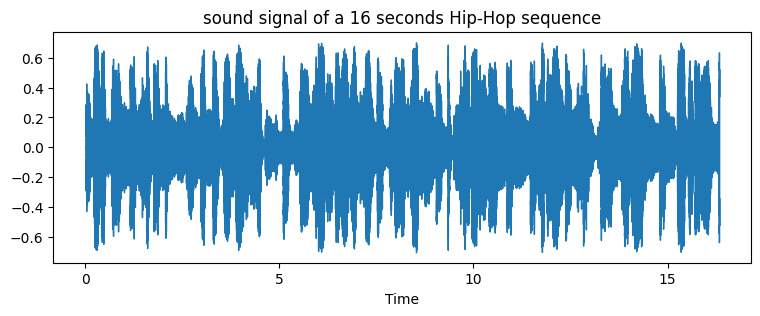

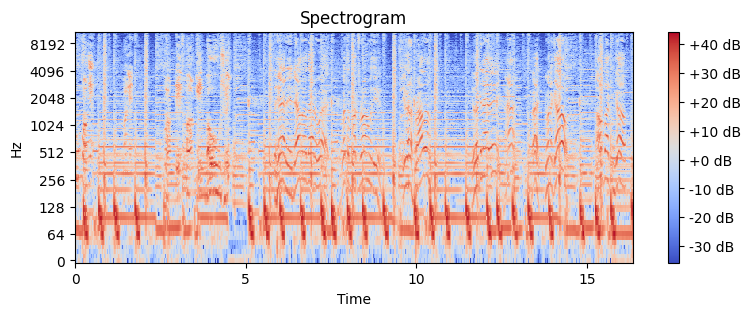

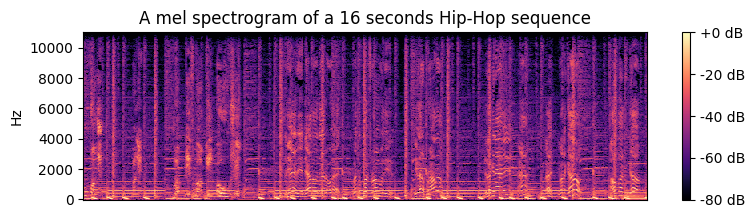

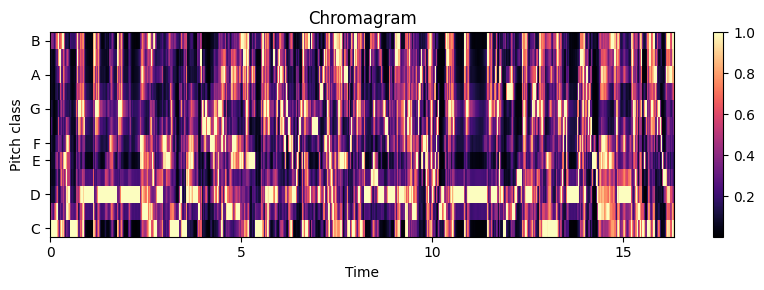

In [ ]:
#@title Data visualization

#Represents the audio sequence in the time domain via compressed wave signals
audio_path = "C:\\Machine_learning_Project_Data\\IA\\data_out\\Hip-Hop\\43.wav"
samples, sample_rate = librosa.load(audio_path, sr=None)
plt.figure(figsize=(9, 3))
librosa.display.waveshow(samples, sr=sample_rate)
plt.title("sound signal of a 16 seconds Hip-Hop sequence")
plt.show()
print("")

#Represents the audio sequence in the frequency domain via spectrogram on a logaritmic scale
samples, sample_rate = librosa.load(audio_path, sr=None)
spectrogram = librosa.stft(samples)
spectrogram_db = librosa.amplitude_to_db(abs(spectrogram))
plt.figure(figsize=(9, 3))
librosa.display.specshow(spectrogram_db, sr=sample_rate, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.show()
print("")

#Represents the audio sequence in the frequency domain via spectrogram on a logaritmic scale this time focusing on the pitch
dat1, sampling_rate1 = librosa.load(audio_path)
plt.figure(figsize=(20, 10))
D = librosa.amplitude_to_db(np.abs(librosa.stft(dat1)), ref=np.max)
plt.subplot(4, 2, 1)
librosa.display.specshow(D, y_axis='linear')
plt.colorbar(format='%+2.0f dB')
plt.title('A mel spectrogram of a 16 seconds Hip-Hop sequence')
plt.show()
print("")

#Represents the audio sequence in the frequency domain via a chroma scale
samples, sample_rate = librosa.load(audio_path, sr=None)
chromagram = librosa.feature.chroma_stft(y=samples, sr=sample_rate, hop_length=512)
plt.figure(figsize=(8.5, 3))
librosa.display.specshow(chromagram, x_axis='time', y_axis='chroma')
plt.colorbar()
plt.title('Chromagram')
plt.tight_layout()
plt.show()


In [ ]:
#@title Data preparation

#Transforms the raw data into a mel spectrogram which is a visual repressentaion of the audio sequence in a way which humans percieve it on a logaritmic scale
def Loader(class_dir,class_name):
  feature = []
  label = []
  # Function to load files and extract features
  for dirpath, dirnames, filenames in os.walk(class_dir):
    print('Dirpath:', dirpath)
    for Individual_file in filenames:
      #kaiser_fast is a technique used for faster extraction
      file_name = dirpath + '\\' + Individual_file
      X, sample_rate = librosa.load(file_name, res_type='kaiser_fast')
      # Here We extract the melspectrogram feature from data
      mels =np.mean(librosa.feature.melspectrogram(y=X, sr=sample_rate).T,axis=0)
      feature.append(mels)
      label.append(class_name)
  return [feature, label]

#This function was previously used but caused a lot of trouble with runtimes and accuracy
# def Wav_to_pitch(class_dir,class_name):
#   feature_mels = []
#   labels = []
#   for dirpath, dirnames, filenames in os.walk(class_dir):
#     print('Dirpath:', dirpath)
#     for Individual_file in filenames:
#       file_name = dirpath + '\\' + Individual_file
#       y, sr = librosa.load(file_name)
#       mels = librosa.feature.melspectrogram(y=y, sr = sr)
#       log_mels = librosa.power_to_db(mels, ref=np.max)
#       reshaped_log_mels = log_mels.reshape(log_mels.shape[0], log_mels.shape[1], 1)
#       feature_mels.append(reshaped_log_mels)
#       labels.append(class_name)
#   return feature_mels,labels

#Add to a list the mel - spectrograms by predecided amounts in order to cut some of the data(intially 45GB)
def add_to_list(Main_mels,Main_labels,mels,labels,Target):
  count = 0
  for i,j in zip(mels,labels):
    if(count == Target):
      break
    else:
      Main_mels.append(i)
      Main_labels.append(j)
      count+=1
  return Main_mels,Main_labels

#summon the loader function and the add_to_list function in order to convert the raw audio into a vectro of the main features of a mel spectrogram
dir = "C:\Machine_learning_Project_Data\IA\data_out"
Main_labels = []
Main_mels = []
saved_Target_index = [495,2000,1500,1214,1500,1044,306,408,945,2000,2000]
for class_name,Tar_index in zip(os.listdir(dir),saved_Target_index):
  feature_mels, labels = Loader(dir + "\\" + class_name,class_name)
  Main_mels, Main_labels = add_to_list(Main_mels,Main_labels,feature_mels,labels,Tar_index)
  print("mels length: ",len(Main_mels))
  print("labels length: ",len(Main_labels))

#removes non matching shapes form a given array by index
def remove_non_matching_shapes_from_array(lst, indexes_to_remove):
    lst = [elem for i, elem in enumerate(lst) if i not in indexes_to_remove]
    return lst

#checks for non matching shapes and printing their indexes
def remove_non_matching_shape(arr_list):
    max_shape = max([arr.shape for arr in arr_list], key=lambda x: x[0])
    to_remove = []
    for i, arr in enumerate(arr_list):
        if arr.shape != max_shape:
            to_remove.append(i)
            print(f"Array at index {i} does not match the maximum shape and will be removed.")
    for i in sorted(to_remove, reverse=True):
        arr_list.pop(i)
    return arr_list

#checks for the max shape in the array and returns it
def max_shape(arr_list):
    shapes = [arr.shape for arr in arr_list]
    max_shape = max(shapes, key=lambda x: x[0])
    for i, arr_shape in enumerate(shapes):
        if arr_shape != max_shape:
            print(f"Array at index {i} does not match the maximum shape")
    return max_shape

print("Main mels shape: ",len(Main_mels))
print("Main lables shape: ",len(Main_labels))

Main_mels = remove_non_matching_shape(Main_mels)

#Transforming the list of arrays(mels) into an array of arrays in order for it to be suitble for CNN
temp = np.array(Main_mels)

#Transforms its shape for it to be suitble
data = temp.transpose()

#saves the labels in array
Lab = np.array(Main_labels)

X_ = temp
Y = Lab
print(X_.shape, Y.shape)

#Transforms a given array of lables into a onehotencode format
def custom_to_categorical(y, num_classes):
    labels, unique_indices = np.unique(y, return_inverse=True)
    one_hot = np.eye(num_classes)[unique_indices]
    return one_hot

num_classes = len(os.listdir(dir))
Y = custom_to_categorical(Y,num_classes)
print("X_ shape: ",X_.shape)
print("Y shape: ",Y.shape)

#split the data for test sets and train sets and also validation sets
X_train, X_test, Y_train, Y_test = train_test_split(X_, Y, random_state = 3)

print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("Y_train", Y_train.shape)
print("Y_test", Y_test)

X_train = X_train.reshape(X_train.shape[0], 16, 8, 1)
X_test = X_test.reshape(X_test.shape[0], 16, 8, 1)

Dirpath: C:\Machine_learning_Project_Data\IA\data_out\Classical
mels length:  495
labels length:  495
Dirpath: C:\Machine_learning_Project_Data\IA\data_out\Electronic
mels length:  2495
labels length:  2495
Dirpath: C:\Machine_learning_Project_Data\IA\data_out\Experimental
mels length:  3995
labels length:  3995
Dirpath: C:\Machine_learning_Project_Data\IA\data_out\Folk
mels length:  5209
labels length:  5209
Dirpath: C:\Machine_learning_Project_Data\IA\data_out\Hip-Hop
mels length:  6709
labels length:  6709
Dirpath: C:\Machine_learning_Project_Data\IA\data_out\Instrumental
mels length:  7753
labels length:  7753
Dirpath: C:\Machine_learning_Project_Data\IA\data_out\Jazz
mels length:  8059
labels length:  8059
Dirpath: C:\Machine_learning_Project_Data\IA\data_out\Old-Time  Historic
mels length:  8467
labels length:  8467
Dirpath: C:\Machine_learning_Project_Data\IA\data_out\Pop
mels length:  9412
labels length:  9412
Dirpath: C:\Machine_learning_Project_Data\IA\data_out\Punk
mels leng

In [ ]:
#@title Crop report
#1- 796 files - "C:\Machine_learning_Project_Data\IA\data_out\Ambient Electronic" - keep
#2- 58 files - blues - terminate
#3- 1181 files - "C:\Machine_learning_Project_Data\IA\data_out\Chiptune  Glitch" - cut to 700
#4- 495 files - "C:\Machine_learning_Project_Data\IA\data_out\Classical" - keep
#5- 142 files - country - terminate
#6- 3071 files - "C:\Machine_learning_Project_Data\IA\data_out\Electronic" - cut to 2000
#7- 1800 files - "C:\Machine_learning_Project_Data\IA\data_out\Experimental" - cut to 1100
#8- 1214 files - "C:\Machine_learning_Project_Data\IA\data_out\Folk" - keep
#9- 1757 files - "C:\Machine_learning_Project_Data\IA\data_out\Hip-Hop" - cut to 1100
#10- 1044 files - "C:\Machine_learning_Project_Data\IA\data_out\Instrumental" - keep
#11- 814 files - "C:\Machine_learning_Project_Data\IA\data_out\International" - keep
#12- 306 files - "C:\Machine_learning_Project_Data\IA\data_out\Jazz" - keep
#13- 408 files - "C:\Machine_learning_Project_Data\IA\data_out\Old-Time  Historic" - keep
#14- 945 files - "C:\Machine_learning_Project_Data\IA\data_out\Pop" - keep
#15- 2582 files - "C:\Machine_learning_Project_Data\IA\data_out\Punk" - cut to 1000
#16- 3095 files - "C:\Machine_learning_Project_Data\IA\data_out\Rock" - cut to 1000
#17- 94 files - soul-rnb - terminated
#18- 94 files - spoken - terminated

In [ ]:
#@title Model creation and reports
input_dim = (16, 8, 1)
#loss: 1.5787 - accuracy: 0.5205
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), padding = "same", input_shape=input_dim),
    tf.keras.layers.LeakyReLU(0.2),
    tf.keras.layers.Conv2D(16, (3,3), padding = "same"),
    tf.keras.layers.LeakyReLU(0.2),
    tf.keras.layers.Conv2D(16, (3,3), padding = "same"),
    tf.keras.layers.LeakyReLU(0.2),
    tf.keras.layers.Conv2D(16, (3,3), padding = "same"),
    tf.keras.layers.LeakyReLU(0.2),
    tf.keras.layers.MaxPool2D((2, 2)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Conv2D(32, (3,3), padding = "same"),
    tf.keras.layers.LeakyReLU(0.2),
    tf.keras.layers.Conv2D(32, (3,3), padding = "same"),
    tf.keras.layers.LeakyReLU(0.2),
    tf.keras.layers.Conv2D(32, (3,3), padding = "same"),
    tf.keras.layers.LeakyReLU(0.2),
    tf.keras.layers.Conv2D(32, (3,3), padding = "same"),
    tf.keras.layers.LeakyReLU(0.2),
    tf.keras.layers.MaxPool2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3,3), padding = "same"),
    tf.keras.layers.LeakyReLU(0.2),
    tf.keras.layers.Conv2D(64, (3,3), padding = "same"),
    tf.keras.layers.LeakyReLU(0.2),
    tf.keras.layers.Conv2D(64, (3,3), padding = "same"),
    tf.keras.layers.LeakyReLU(0.2),
    tf.keras.layers.Conv2D(64, (3,3), padding = "same"),
    tf.keras.layers.LeakyReLU(0.2),
    tf.keras.layers.MaxPool2D((2, 2)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024),
    tf.keras.layers.LeakyReLU(0.2),
    tf.keras.layers.Dense(11, activation='softmax')
])
model.summary()
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

# loss: 1.7167 - accuracy: 0.4794
# model = tf.keras.models.Sequential([
#     tf.keras.layers.Conv2D(32, (3,3), padding = "same", activation='relu', input_shape=input_dim),
#     tf.keras.layers.MaxPool2D((2, 2)),
#     tf.keras.layers.Conv2D(128, (3,3), padding = "same", activation='relu'),
#     tf.keras.layers.MaxPool2D((2, 2)),
#     tf.keras.layers.Dropout(0.3),
#     tf.keras.layers.Conv2D(128, (3,3), padding = "same", activation='relu'),
#     tf.keras.layers.MaxPool2D((2, 2)),
#     tf.keras.layers.Dropout(0.3),
#     tf.keras.layers.Flatten(),
#     tf.keras.layers.Dense(1024, activation='relu'),
#     tf.keras.layers.Dense(10, activation='softmax')
# ])
# model.summary()
# model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

#loss: 2.6015 - accuracy: 0.4780
#model = tf.keras.models.Sequential([
#     tf.keras.layers.Conv2D(32, (3,3), padding = "same", activation='tanh', input_shape=input_dim),
#     tf.keras.layers.MaxPool2D((2, 2)),
#     tf.keras.layers.Conv2D(128, (3,3), padding = "same", activation='tanh'),
#     tf.keras.layers.MaxPool2D((2, 2)),
#     tf.keras.layers.Dropout(0.3),
#     tf.keras.layers.Conv2D(128, (3,3), padding = "same", activation='tanh'),
#     tf.keras.layers.MaxPool2D((2, 2)),
#     tf.keras.layers.Dropout(0.3),
#     tf.keras.layers.Flatten(),
#     tf.keras.layers.Dense(1024, activation='tanh'),
#     tf.keras.layers.Dense(10, activation='softmax')
# ])
# model.summary()
# model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 16, 8, 16)         160       
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 16, 8, 16)         0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 16, 8, 16)         2320      
_________________________________________________________________
leaky_re_lu_1 (LeakyReLU)    (None, 16, 8, 16)         0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 16, 8, 16)         2320      
_________________________________________________________________
leaky_re_lu_2 (LeakyReLU)    (None, 16, 8, 16)         0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 16, 8, 16)         2

In [ ]:
#@title Fit and evaluate

#Trains the model on 50 epochs, uses the test set as validation data
epochs=50
history = model.fit(X_train,Y_train,validation_data = (X_test, Y_test),epochs=epochs)

Epoch 1/50
315/315 [==============================] - 3s 8ms/step - loss: 2.0550 - accuracy: 0.2424 - val_loss: 1.8528 - val_accuracy: 0.3331
Epoch 2/50
315/315 [==============================] - 2s 7ms/step - loss: 1.8446 - accuracy: 0.3260 - val_loss: 1.7911 - val_accuracy: 0.3486
Epoch 3/50
315/315 [==============================] - 3s 8ms/step - loss: 1.7659 - accuracy: 0.3560 - val_loss: 1.7195 - val_accuracy: 0.3701
Epoch 4/50
315/315 [==============================] - 3s 8ms/step - loss: 1.7212 - accuracy: 0.3762 - val_loss: 1.7530 - val_accuracy: 0.3543
Epoch 5/50
315/315 [==============================] - 3s 8ms/step - loss: 1.6853 - accuracy: 0.3938 - val_loss: 1.7755 - val_accuracy: 0.3600
Epoch 6/50
315/315 [==============================] - 2s 7ms/step - loss: 1.6705 - accuracy: 0.3993 - val_loss: 1.7116 - val_accuracy: 0.3797
Epoch 7/50
315/315 [==============================] - 2s 7ms/step - loss: 1.6406 - accuracy: 0.4121 - val_loss: 1.6484 - val_accuracy: 0.4098
Epoch 

In [ ]:
#@title Load and evaluate the model
model = load_model("C:\Machine_learning_Project_Data\IA\Trained model 2")
model.evaluate(X_test, Y_test)

105/105 [==============================] - 8s 3ms/step - loss: 1.8026 - accuracy: 0.4417


[1.802640438079834, 0.4416939914226532]

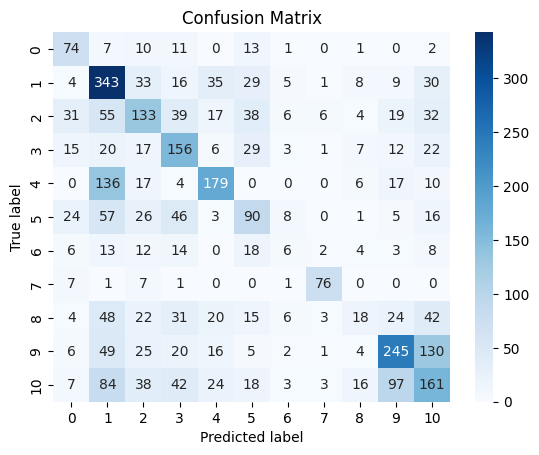

              precision    recall  f1-score   support

           0       0.42      0.62      0.50       119
           1       0.42      0.67      0.52       513
           2       0.39      0.35      0.37       380
           3       0.41      0.54      0.47       288
           4       0.60      0.49      0.54       369
           5       0.35      0.33      0.34       276
           6       0.15      0.07      0.09        86
           7       0.82      0.82      0.82        93
           8       0.26      0.08      0.12       233
           9       0.57      0.49      0.52       503
          10       0.36      0.33      0.34       493

    accuracy                           0.44      3353
   macro avg       0.43      0.43      0.42      3353
weighted avg       0.44      0.44      0.43      3353



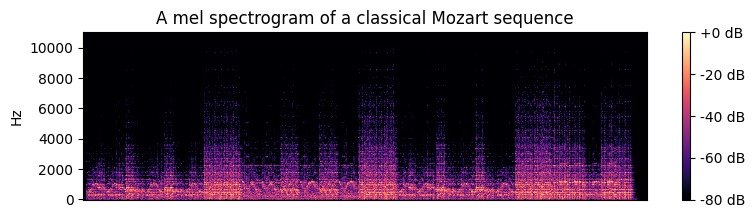

Prediction: Classical
True label: Classical


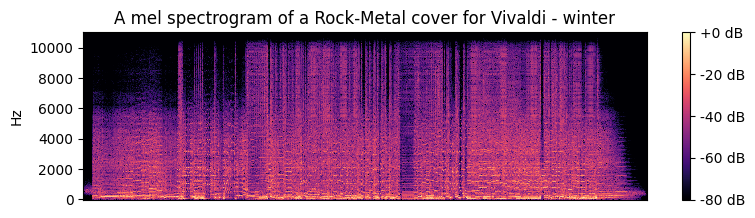

Prediction: Rock
True label: Rock


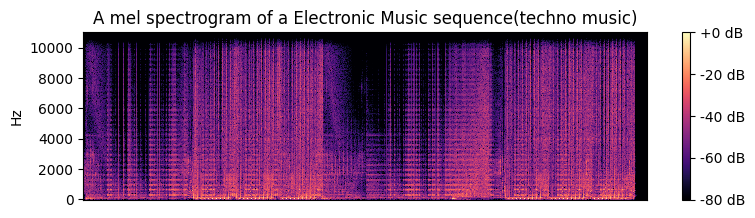

Prediction: Electronic
True label: Electronic


In [ ]:
#@title Visualizing test predictions

def predict(x):
  Sound = x.reshape(1,16, 8,1)
  pred1 = model.predict(Sound)
  pred2 = np.argmax(pred1)
  return pred2

predicted_labels = []
for x in X_test:
  predicted_labels.append(predict(x))

# Convert one-hot encoded labels to class indices
true_labels = np.argmax(Y_test, axis=1)

# Create confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Create heatmap
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")

# Add labels and title
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

# Show plot
plt.show()

report = classification_report(true_labels,predicted_labels)

print(report)

classes = os.listdir(dir)

def create_mel(audio_path,title):
  dat1, sampling_rate1 = librosa.load(audio_path)
  plt.figure(figsize=(20, 10))
  D = librosa.amplitude_to_db(np.abs(librosa.stft(dat1)), ref=np.max)
  plt.subplot(4, 2, 1)
  librosa.display.specshow(D, y_axis='linear')
  plt.colorbar(format='%+2.0f dB')
  plt.title(title)
  plt.show()

def classify_music(file_path):
  X, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
  mel =np.mean(librosa.feature.melspectrogram(y=X, sr=sample_rate).T,axis=0)
  Sound=mel.reshape(1,16, 8,1)
  Sound.shape
  pred1= model.predict(Sound)
  pred2 = np.argmax(pred1)
  genre = classes[pred2]
  return genre

audio_path1 = "C:\\Users\\Riporter\\OneDrive\שולחן העבודה\\music test\\Rondo Alla Turca- Mozart.wav"
title1 = 'A mel spectrogram of a classical Mozart sequence'
create_mel(audio_path1,title1)

print("Prediction: " + classify_music(audio_path1))
print("True label: Classical" )

audio_path2 = "C:\\Users\\Riporter\\OneDrive\\שולחן העבודה\\music test\\Vivaldi - Winter (Metal Edition).wav"
title2 = 'A mel spectrogram of a Rock-Metal cover for Vivaldi - winter'
create_mel(audio_path2,title2)

print("Prediction: " + classify_music(audio_path2))
print("True label: Rock" )

audio_path3 = "C:\\Users\\Riporter\\OneDrive\\שולחן העבודה\\music test\\Tujamo, VINNE & Murotani - Techno Party (Bass House ⧸ Tech House).wav"
title3 = 'A mel spectrogram of a Electronic Music sequence(techno music)'
create_mel(audio_path3,title3)

print("Prediction: " + classify_music(audio_path3))
print("True label: Electronic" )